# 0. Import library

In [23]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
    print("cuda is available")
else:
    print("cuda is NOT available")

import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


cuda is available


# 1-1. Import Data 

In [24]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


## 1-2. Normalize data

In [25]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [26]:
class scalers():
    def __init__(self,x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max
        self.x_min = x_min
        self.y_max = y_max
        self.y_min = y_min
        
        return None
    
    def scaler_x(self, x_original, dim_id = -1):
        if dim_id == -1:
            x_s = -1 + 2 * ((x_original - self.x_min) / (self.x_max-self.x_min))
            return x_s
        else: 
            x_s = -1 + 2 * (x_original - self.x_min[0,dim_id]) / (self.x_max[0,dim_id] - self.x_min[0,dim_id])
            return x_s
    
    def inv_scaler_x(self, x_s, dim_id = -1):
        
        if dim_id == -1:
            x_original = (x_s + 1)*0.5*(self.x_max-self.x_min) + self.x_min
            return x_original
        else: 
            x_original = (x_s + 1)*0.5*(self.x_max[0,dim_id] - self.x_min[0,dim_id]) + self.x_min[0,dim_id]
            return x_original
        
    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max-self.y_min))
    
    def inv_scaler_y(self, y_s):
        return (y_s + 1)*0.5*(self.y_max-self.y_min) + self.y_min

In [27]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original_scale)
y_s = scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))

print("x_s shape:", x_s.shape)
print("y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4)
y_s shape: (610417, 2)


## 1-3. Generate data

In [28]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

e = 0.0001
y_depth_low = np.random.uniform(0.1423-e, 0.1423+e, size = (length,1))
y_depth_up = np.random.uniform(0.4126-e, 0.4126+e, size = (length,1))
# constraints!
#y_depth_low = 0*np.random.uniform(0.0, 0.5, size=(length, 1))
#y_depth_up = 0*np.random.uniform(0.5, 1.0, size=(length, 1))

y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [29]:
import numpy as np
import pandas as pd
import torch
import copy
from tqdm import tqdm

# =====================================================
# 1. Load & preprocess raw data
# =====================================================
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')

print(df_all.shape)
print(df_all.columns)

# ---- global time index (핵심) ----
df_all = df_all.reset_index(drop=True)
df_all["time_id"] = np.arange(len(df_all))

# ---- NaN handling (time_id 유지) ----
nan_rows = df_all[df_all.isna().any(axis=1)]
df_all = df_all.dropna().reset_index(drop=True)

# =====================================================
# 2. Feature extraction
# =====================================================
loc_Z = df_all["Z"].to_numpy().reshape(-1, 1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1, 1)

# ---- global time id ----
time_id_all = df_all["time_id"].to_numpy()

# =====================================================
# 3. Melt pool smoothing
# =====================================================
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw, 4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1, 1)

mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw, 4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1, 1)

# =====================================================
# 4. Stack original-scale arrays
# =====================================================
x_original = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)  # (N,4)
y_original = np.concatenate((mp_temp, mp_depth), axis=1)                  # (N,2)

# =====================================================
# 5. Scaling (-1 ~ 1)
# =====================================================
x_max = np.max(x_original, axis=0, keepdims=True)
x_min = np.min(x_original, axis=0, keepdims=True)
y_max = np.max(y_original, axis=0, keepdims=True)
y_min = np.min(y_original, axis=0, keepdims=True)

scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original)
y_s = scaler.scaler_y(y_original)

# =====================================================
# 6. Reference / Constraint (global arrays)
# =====================================================
length = y_s.shape[0]

# =====================================================
# Global reference (temperature)
# =====================================================
y_ref_global = y_s[:, 0:1]   # (N, 1)


# depth constraint (global)
e = 1e-4
y_depth_low = np.random.uniform(0.1423 - e, 0.1423 + e, size=(length, 1))
y_depth_up  = np.random.uniform(0.4126 - e, 0.4126 + e, size=(length, 1))
y_const_global = np.concatenate((y_depth_low, y_depth_up), axis=1)  # (N,2)

# =====================================================
# 7. Train / Validation split (time-consistent)
# =====================================================
cutoff_index = int(np.round(0.8 * length))

x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val,   y_val   = x_s[cutoff_index:], y_s[cutoff_index:]

time_id_train = time_id_all[:cutoff_index]
time_id_val   = time_id_all[cutoff_index:]

# =====================================================
# 7. (삭제/변경) Train/Val split을 먼저 하지 말고
#    8번에서 전체 샘플을 먼저 만든 뒤 shuffle split
# =====================================================

window = 50
P = 50
N = length

# 전체에서 만들 수 있는 샘플 개수
# i는 "현재 시점(start of future)" 인덱스
# i는 [window, N-P) 범위
n_all = (N - P) - window

x_past_all = np.empty((n_all, window, 4))
y_past_all = np.empty((n_all, window, 2))
x_future_all = np.empty((n_all, P, 3))
y_ref_all_seq = np.empty((n_all, P, 1))
y_const_all_seq = np.empty((n_all, P, 2))
time_idx_all_seq = np.empty(n_all, dtype=np.int64)

for i in tqdm(range(window, N - P)):
    j = i - window

    x_past_all[j] = x_s[i-window:i]
    y_past_all[j] = y_s[i-window:i]
    x_future_all[j] = x_s[i:i+P, :3]

    # reference
    scalar_shift = 0
    y_ref_all_seq[j] = y_ref_global[i:i+P] + scalar_shift

    # constraint
    y_const_all_seq[j] = y_const_global[i:i+P]

    # time index (글로벌)
    time_idx_all_seq[j] = time_id_all[i]

# =====================================================
# 8. Shuffle 후 8:2 split (샘플 단위)
# =====================================================
rng = np.random.default_rng(42)  # 재현성
perm = rng.permutation(n_all)

cut = int(np.round(0.8 * n_all))
train_idx = perm[:cut]
val_idx   = perm[cut:]

x_past_train = x_past_all[train_idx]
y_past_train = y_past_all[train_idx]
x_future_train = x_future_all[train_idx]
y_ref_train_seq = y_ref_all_seq[train_idx]
y_const_train_seq = y_const_all_seq[train_idx]
time_idx_train = time_idx_all_seq[train_idx]

x_past_val = x_past_all[val_idx]
y_past_val = y_past_all[val_idx]
x_future_val = x_future_all[val_idx]
y_ref_val_seq = y_ref_all_seq[val_idx]
y_const_val_seq = y_const_all_seq[val_idx]
time_idx_val = time_idx_all_seq[val_idx]

# =====================================================
# 9. Torch tensor conversion
# =====================================================
x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)
time_idx_train = torch.tensor(time_idx_train, dtype=torch.long)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)
time_idx_val = torch.tensor(time_idx_val, dtype=torch.long)


# =====================================================
# 10. Shape check
# =====================================================
print("Train shapes:")
print("x_past:", x_past_train.shape)
print("y_past:", y_past_train.shape)
print("x_future:", x_future_train.shape)
print("y_ref:", y_ref_train_seq.shape)
print("y_const:", y_const_train_seq.shape)
print("time_idx:", time_idx_train.shape)

print("\nVal shapes:")
print("x_past:", x_past_val.shape)
print("y_past:", y_past_val.shape)
print("x_future:", x_future_val.shape)
print("y_ref:", y_ref_val_seq.shape)
print("y_const:", y_const_val_seq.shape)
print("time_idx:", time_idx_val.shape)


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
batch_size = 256

# ------------------ Training loader ------------------
train_dataset = TensorDataset(
    x_past_train,
    y_past_train,
    x_future_train,
    y_ref_train_seq,
    y_const_train_seq,
    time_idx_train          # ⭐ 반드시 포함
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True           # ⭐ 핵심 수정
)

# ------------------ Validation loader ------------------
val_dataset = TensorDataset(
    x_past_val,
    y_past_val,
    x_future_val,
    y_ref_val_seq,
    y_const_val_seq,
    time_idx_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 3. Import TiDE model (NN model)

In [ ]:
import torch
import pickle

# Load model
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    nominal_params = pickle.load(file)

TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())

## 4. UQ

In [85]:
import os
import pickle
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

def print_timestep_values(idx, name, y_true_1d, y_low_1d, y_mid_1d, y_high_1d, mc_samples_mid_2d=None):
    """
    y_*_1d: torch.Tensor shape (T,) or (T,1)
    mc_samples_mid_2d: torch.Tensor shape (K,T) or (K,T,1) or (K,1,T,1) 등 -> 내부에서 (K,T)로 정리
    """
    def to_1d_torch(x):
        if x.ndim == 2 and x.shape[1] == 1:
            return x[:, 0]
        if x.ndim == 1:
            return x
        raise ValueError(f"Expected (T,) or (T,1), got {tuple(x.shape)}")

    yt = to_1d_torch(y_true_1d.detach().cpu())
    yl = to_1d_torch(y_low_1d.detach().cpu())
    ym = to_1d_torch(y_mid_1d.detach().cpu())
    yh = to_1d_torch(y_high_1d.detach().cpu())

    T = ym.shape[0]
    if not (yt.shape[0] == yl.shape[0] == yh.shape[0] == T):
        raise ValueError(f"[print] Length mismatch: yt={yt.shape[0]}, yl={yl.shape[0]}, ym={T}, yh={yh.shape[0]}")

    mc_mean = mc_std = None
    if mc_samples_mid_2d is not None:
        s = mc_samples_mid_2d.detach().cpu()

        # 가능한 shape들을 (K,T)로 정규화
        if s.ndim == 4:
            # 예: (K,1,T,1)
            s = s[:, 0, :, 0]
        elif s.ndim == 3:
            # 예: (K,T,1)
            s = s[:, :, 0]
        elif s.ndim == 2:
            # (K,T)
            pass
        else:
            raise ValueError(f"mc_samples_mid unexpected shape: {tuple(s.shape)}")

        if s.shape[1] != T:
            raise ValueError(f"mc_samples_mid T mismatch: expected {T}, got {s.shape[1]}")

        mc_mean = s.mean(dim=0)  # (T,)
        mc_std  = s.std(dim=0)   # (T,)

    # 출력
    print(f"\n===== Val idx={idx} | {name} | T={T} =====")
    header = "t\ttrue\t\tlow\t\tmid\t\thigh"
    if mc_mean is not None:
        header += "\t\tmc_mean\t\tmc_std"
    print(header)

    for t in range(T):
        if mc_mean is None:
            print(f"{t:02d}\t{yt[t]: .6f}\t{yl[t]: .6f}\t{ym[t]: .6f}\t{yh[t]: .6f}")
        else:
            print(f"{t:02d}\t{yt[t]: .6f}\t{yl[t]: .6f}\t{ym[t]: .6f}\t{yh[t]: .6f}\t{mc_mean[t]: .6f}\t{mc_std[t]: .6f}")

# =========================================================
# 0) Dropout only enable (for TiDE MC dropout)
# =========================================================
def enable_dropout_only(model: nn.Module):
    model.eval()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.Dropout1d, nn.Dropout2d, nn.Dropout3d)):
            m.train()

# =========================================================
# 1) get single sample from val_dataset by index
# =========================================================
def get_val_sample(val_dataset, idx, device):
    x_past, y_past, x_future, y_ref, y_const, time_idx = val_dataset[idx]
    x_past   = x_past.unsqueeze(0).to(device)
    y_past   = y_past.unsqueeze(0).to(device)
    x_future = x_future.unsqueeze(0).to(device)
    y_ref    = y_ref.unsqueeze(0).to(device)
    y_const  = y_const.unsqueeze(0).to(device)
    if torch.is_tensor(time_idx):
        time_idx = time_idx.unsqueeze(0).to(device)
    else:
        time_idx = torch.tensor([time_idx], device=device)
    return x_past, y_past, x_future, y_ref, y_const, time_idx

# =========================================================
# 2) policy deterministic -> u_output, then TiDE quantiles
# =========================================================
@torch.no_grad()
def run_policy_then_tide_quantiles(policy_model, tide_model,
                                  x_past, y_past, x_future, y_ref, y_const, time_idx):
    # policy deterministic
    policy_model.eval()
    policy_in_past   = torch.cat((x_past, y_past), dim=2)
    policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)
    u_output = policy_model((policy_in_past, policy_in_future))  # [B, 50, 1] 가정

    # TiDE input
    x_future_tide = torch.cat((x_future, u_output), dim=2)
    past_cov      = torch.cat((y_past, x_past), dim=2)

    tide_model.eval()
    out = tide_model((past_cov, x_future_tide, None))

    # ---- debug prints (kept) ----
    print("DEBUG TiDE out type:", type(out))
    if torch.is_tensor(out):
        print("DEBUG TiDE out shape:", tuple(out.shape))
    elif isinstance(out, dict):
        print("DEBUG TiDE out keys:", list(out.keys()))
    elif isinstance(out, (tuple, list)):
        print("DEBUG TiDE out list/tuple len:", len(out))
        print("DEBUG element types:", [type(o) for o in out])
        print("DEBUG element shapes:", [tuple(o.shape) for o in out if torch.is_tensor(o)])

    # ---- TiDE output parsing ----
    if torch.is_tensor(out):
        # out: [B, P, D, Q] or [B, P, D]
        if out.ndim == 4:
            Q = out.shape[-1]

            # 가장 흔한 케이스: Q=3 (low/mid/high)
            if Q == 3:
                y_low  = out[..., 0]  # [B,P,D]
                y_mid  = out[..., 1]  # [B,P,D]
                y_high = out[..., 2]  # [B,P,D]
            else:
                # 일반 케이스: 양 끝을 low/high, 가운데를 mid로 사용
                mid_idx = Q // 2
                y_low  = out[..., 0]
                y_mid  = out[..., mid_idx]
                y_high = out[..., -1]

        elif out.ndim == 3:
            # 이미 [B,P,D] 형태면 quantile 축이 없는 것으로 보고 동일값 처리
            y_low = y_mid = y_high = out

        else:
            raise ValueError(f"Unexpected TiDE tensor shape: {tuple(out.shape)}")

    elif isinstance(out, dict):
        # dict는 키가 다를 수도 있으니 안전하게 확인
        if not all(k in out for k in ("low", "mid", "high")):
            raise ValueError(f"TiDE dict keys mismatch. keys={list(out.keys())}")
        y_low, y_mid, y_high = out["low"], out["mid"], out["high"]

    elif isinstance(out, (tuple, list)) and len(out) == 3:
        y_low, y_mid, y_high = out

    else:
        raise ValueError(f"TiDE output type not recognized: {type(out)}")

    # ✅ 반드시 반환 (이게 없어서 None이 나왔던 것)
    return u_output, (past_cov, x_future_tide), (y_low, y_mid, y_high)


# =========================================================
# 3) TiDE MC dropout samples (mid only)
# =========================================================
@torch.no_grad()
@torch.no_grad()
def tide_mc_dropout_samples(tide_model, past_cov, x_future_tide, K=50):
    enable_dropout_only(tide_model)
    samples = []
    for _ in range(K):
        out = tide_model((past_cov, x_future_tide, None))  # (1,50,2,3)
        samples.append(out[..., 1].unsqueeze(0))           # mid -> (1,1,50,2)
    tide_model.eval()
    return torch.cat(samples, dim=0)                       # (K,1,50,2)


# =========================================================
# 4) plotting
# =========================================================
def _to_1d_np(x):
    x = x.detach().cpu()
    if x.ndim == 2 and x.shape[-1] == 1:
        x = x[:, 0]
    return x.numpy()

def plot_tide_uq(y_true, y_low, y_mid, y_high, mc_samples_mid=None, title=""):
    """
    Expected shapes (strict):
      - y_true, y_low, y_mid, y_high: (T,) or (T,1)
      - mc_samples_mid (optional): (K,T) or (K,T,1)
    If inputs do not match, raise ValueError with a clear message.
    """
    def to_1d(x, name):
        if x is None:
            raise ValueError(f"{name} is None")

        if not torch.is_tensor(x):
            raise ValueError(f"{name} must be a torch.Tensor. Got {type(x)}")

        x = x.detach().cpu()

        if x.ndim == 1:
            return x.numpy()  # (T,)
        if x.ndim == 2 and x.shape[1] == 1:
            return x[:, 0].numpy()  # (T,1) -> (T,)

        raise ValueError(f"{name} must have shape (T,) or (T,1). Got {tuple(x.shape)}")

    yt = to_1d(y_true, "y_true")
    yl = to_1d(y_low,  "y_low")
    ym = to_1d(y_mid,  "y_mid")
    yh = to_1d(y_high, "y_high")

    # length consistency
    T = ym.shape[0]
    if not (yt.shape[0] == yl.shape[0] == yh.shape[0] == T):
        raise ValueError(
            f"Length mismatch: y_mid={T}, y_true={yt.shape[0]}, y_low={yl.shape[0]}, y_high={yh.shape[0]}"
        )

    t = np.arange(T)

    plt.figure(figsize=(11, 4))
    plt.plot(t, yt, label="y_ref/true")
    plt.plot(t, ym, label="TiDE mid")
    plt.fill_between(t, yl, yh, alpha=0.25, label="quantile band (0.05-0.95)")

    if mc_samples_mid is not None:
        if not torch.is_tensor(mc_samples_mid):
            raise ValueError(f"mc_samples_mid must be torch.Tensor. Got {type(mc_samples_mid)}")

        s = mc_samples_mid.detach().cpu()

        # strict shape checks
        if s.ndim == 2:
            # (K,T)
            if s.shape[1] != T:
                raise ValueError(f"mc_samples_mid shape mismatch: expected (K,{T}), got {tuple(s.shape)}")
            s_np = s.numpy()

        elif s.ndim == 3:
            # (K,T,1)
            if s.shape[1] != T or s.shape[2] != 1:
                raise ValueError(f"mc_samples_mid shape mismatch: expected (K,{T},1), got {tuple(s.shape)}")
            s_np = s[:, :, 0].numpy()  # -> (K,T)

        else:
            raise ValueError(f"mc_samples_mid must have shape (K,T) or (K,T,1). Got {tuple(s.shape)}")

        mean = s_np.mean(axis=0)  # (T,)
        std  = s_np.std(axis=0)   # (T,)

        plt.fill_between(t, mean - 1.64*std, mean + 1.64*std, alpha=0.18, label="MC dropout ±2σ")

    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# =========================================================
# 5) MAIN: load POLICY + TiDE, run on selected val indices
# =========================================================
def run_uq_on_val_indices(
    indices,
    val_dataset,
    device,
    policy_hidden_dim,
    policy_n_layers,
    policy_ckpt_path,
    tide_pkl_path,
    mc_K=50
):
    # ---------- load TiDE ----------
    with open(tide_pkl_path, "rb") as f:
        nominal_params = pickle.load(f)
    TiDE = nominal_params["model"].to(device)
    TiDE.eval()

    # ---------- load POLICY ----------
    policy_model = PolicyNN(
        past_input_dim=6,
        future_input_dim=6,
        output_dim=1,
        p=50,
        window=50,
        hidden_dim=policy_hidden_dim,
        n_layers=policy_n_layers,
        dropout_p=0.1
    ).to(device)

    state_dict = torch.load(policy_ckpt_path, map_location=device)
    policy_model.load_state_dict(state_dict)
    policy_model.eval()

    print(f"[Loaded] POLICY ckpt: {policy_ckpt_path}")
    print(f"[Loaded] TiDE pkl: {tide_pkl_path}")

    for idx in indices:
        x_past, y_past, x_future, y_ref, y_const, time_idx = get_val_sample(val_dataset, idx, device)

        u_output, (past_cov, x_future_tide), (y_low, y_mid, y_high) = run_policy_then_tide_quantiles(
            policy_model, TiDE, x_past, y_past, x_future, y_ref, y_const, time_idx
        )

        mc_samples = tide_mc_dropout_samples(TiDE, past_cov, x_future_tide, K=mc_K)  # [K,1,T,D]

        for d, name in [(0, "temp"), (1, "depth")]:
            # ---- 50 타임스텝 값 출력 ----
            # NOTE: 지금 코드에서는 y_true를 y_ref[0]로 두고 있는데,
            # y_ref가 (T,2)면 d에 맞춰서 슬라이스해야 함.
            y_true_d = y_ref[0, :, d:d+1] if (y_ref.ndim == 3 and y_ref.shape[-1] >= 2) else y_ref[0]

            print_timestep_values(
                idx=idx,
                name=name,
                y_true_1d=y_true_d,
                y_low_1d=y_low[0, :, d:d+1],
                y_mid_1d=y_mid[0, :, d:d+1],
                y_high_1d=y_high[0, :, d:d+1],
                mc_samples_mid_2d=mc_samples[:, 0, :, d:d+1],  # (K,T,1)로 들어감
            )

            # ---- 플롯 ----
            plot_tide_uq(
                y_true=y_true_d,
                y_low=y_low[0, :, d:d+1],
                y_mid=y_mid[0, :, d:d+1],
                y_high=y_high[0, :, d:d+1],
                mc_samples_mid=mc_samples[:, 0, :, d:d+1],
                title=f"Val idx={idx} | {name} | MC K={mc_K}"
            )

    return policy_model, TiDE  # <-- 파이썬 주석은 # 로!



[Loaded] POLICY ckpt: /home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/policy_model.pth
[Loaded] TiDE pkl: TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl
DEBUG TiDE out type: <class 'torch.Tensor'>
DEBUG TiDE out shape: (1, 50, 2, 3)

===== Val idx=100 | temp | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.936517	 0.728321	 0.893057	 0.900777	 0.890677	 0.021247
01	 0.932341	 0.732650	 0.899999	 0.897641	 0.898254	 0.019846
02	 0.929137	 0.740089	 0.895016	 0.893592	 0.896551	 0.018888
03	 0.924653	 0.741325	 0.891933	 0.888357	 0.891668	 0.025549
04	 0.922481	 0.736162	 0.888825	 0.887504	 0.885160	 0.021376
05	 0.922209	 0.725622	 0.886407	 0.888309	 0.886785	 0.021482
06	 0.920655	 0.713960	 0.882399	 0.886708	 0.881042	 0.019263
07	 0.920188	 0.702979	 0.879162	 0.885094	 0.878366	 0.018044
08	 0.919849	 0.695071	 0.878206	 0.883962	 0.878110	 0.017586
09	 0.919741	 0.691408	 0.881328	 0.8

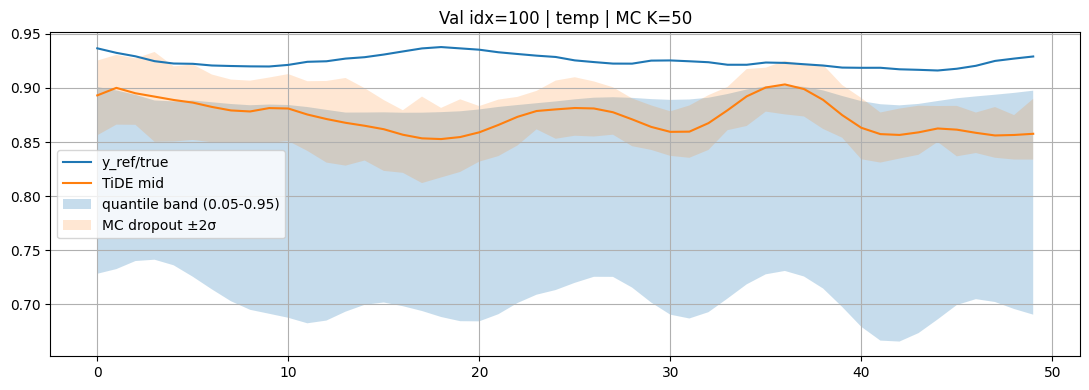


===== Val idx=100 | depth | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.936517	 0.364349	 0.461783	 0.443886	 0.455594	 0.024954
01	 0.932341	 0.338956	 0.429809	 0.418838	 0.426543	 0.032189
02	 0.929137	 0.322599	 0.419218	 0.401686	 0.412399	 0.023956
03	 0.924653	 0.309636	 0.414074	 0.393444	 0.411967	 0.025756
04	 0.922481	 0.299352	 0.409806	 0.384959	 0.408589	 0.026410
05	 0.922209	 0.287274	 0.404918	 0.377255	 0.405123	 0.026510
06	 0.920655	 0.274295	 0.398974	 0.372520	 0.394249	 0.019086
07	 0.920188	 0.260949	 0.391053	 0.367397	 0.396456	 0.022376
08	 0.919849	 0.248508	 0.382152	 0.359904	 0.383339	 0.018982
09	 0.919741	 0.241727	 0.375452	 0.353922	 0.375565	 0.020349
10	 0.921216	 0.239308	 0.378238	 0.351995	 0.377475	 0.016581
11	 0.924061	 0.240495	 0.392571	 0.353981	 0.389789	 0.017112
12	 0.924556	 0.245072	 0.405426	 0.355538	 0.407443	 0.019290
13	 0.927031	 0.253070	 0.417059	 0.358398	 0.416568	 0.023525
14	 0.928324	 0.261808	 0.426931	 0.36

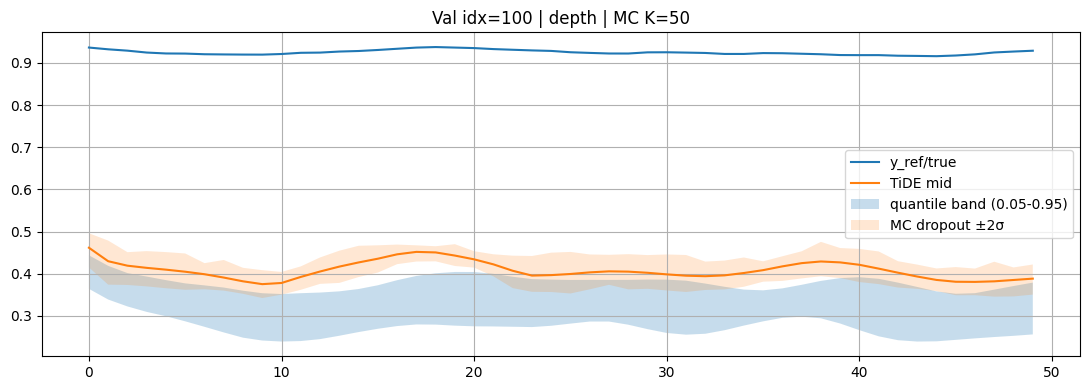

DEBUG TiDE out type: <class 'torch.Tensor'>
DEBUG TiDE out shape: (1, 50, 2, 3)

===== Val idx=1020 | temp | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.600262	 0.606566	 0.611253	 0.604703	 0.611349	 0.004180
01	 0.624320	 0.603602	 0.615035	 0.615977	 0.614732	 0.003169
02	 0.623609	 0.592457	 0.616853	 0.623325	 0.616925	 0.002540
03	 0.627028	 0.581634	 0.616799	 0.628361	 0.616607	 0.002518
04	 0.626380	 0.581248	 0.615675	 0.627610	 0.615567	 0.002621
05	 0.623905	 0.584169	 0.615002	 0.626903	 0.614621	 0.002612
06	 0.621997	 0.588810	 0.613916	 0.626327	 0.613924	 0.002358
07	 0.620792	 0.592791	 0.612321	 0.625587	 0.612289	 0.001840
08	 0.618362	 0.595848	 0.610495	 0.624892	 0.610514	 0.002250
09	 0.614858	 0.597590	 0.608884	 0.624244	 0.608804	 0.002172
10	 0.612083	 0.598501	 0.608246	 0.623762	 0.608117	 0.002096
11	 0.610785	 0.598753	 0.608072	 0.623500	 0.607896	 0.002094
12	 0.611268	 0.598609	 0.607421	 0.623072	 0.607644	 0.002581
13	 0.611214	 0.59849

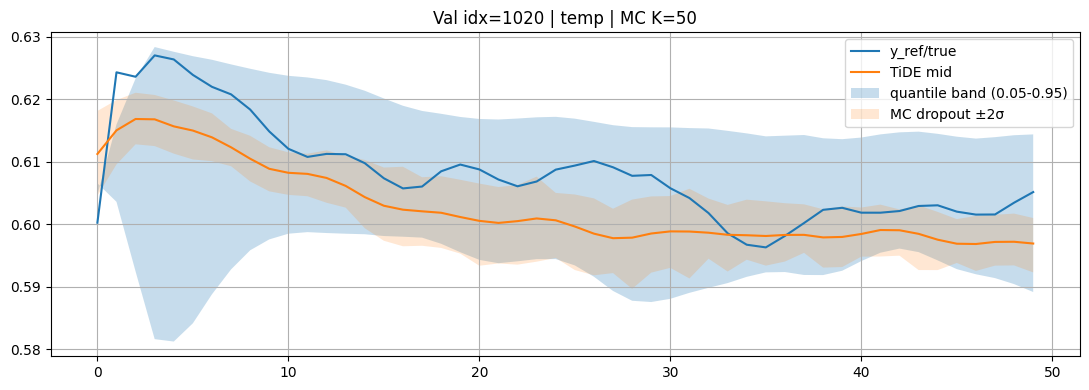


===== Val idx=1020 | depth | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.600262	 0.223454	 0.253692	 0.253835	 0.253456	 0.007177
01	 0.624320	 0.248783	 0.278075	 0.288978	 0.277667	 0.008949
02	 0.623609	 0.267842	 0.303526	 0.324758	 0.303325	 0.006641
03	 0.627028	 0.281588	 0.323819	 0.355154	 0.323505	 0.007100
04	 0.626380	 0.283036	 0.327379	 0.359201	 0.326612	 0.007172
05	 0.623905	 0.283540	 0.327490	 0.359948	 0.326871	 0.006570
06	 0.621997	 0.283486	 0.326404	 0.358868	 0.325455	 0.006754
07	 0.620792	 0.282953	 0.324967	 0.357870	 0.324925	 0.006068
08	 0.618362	 0.281321	 0.322620	 0.356425	 0.321877	 0.005616
09	 0.614858	 0.278573	 0.319547	 0.354480	 0.319900	 0.006155
10	 0.612083	 0.275083	 0.315335	 0.351237	 0.314783	 0.005750
11	 0.610785	 0.271832	 0.311325	 0.348565	 0.310727	 0.005346
12	 0.611268	 0.268830	 0.307904	 0.346815	 0.307894	 0.004762
13	 0.611214	 0.266066	 0.305303	 0.345465	 0.305679	 0.005943
14	 0.609787	 0.263291	 0.303543	 0.3

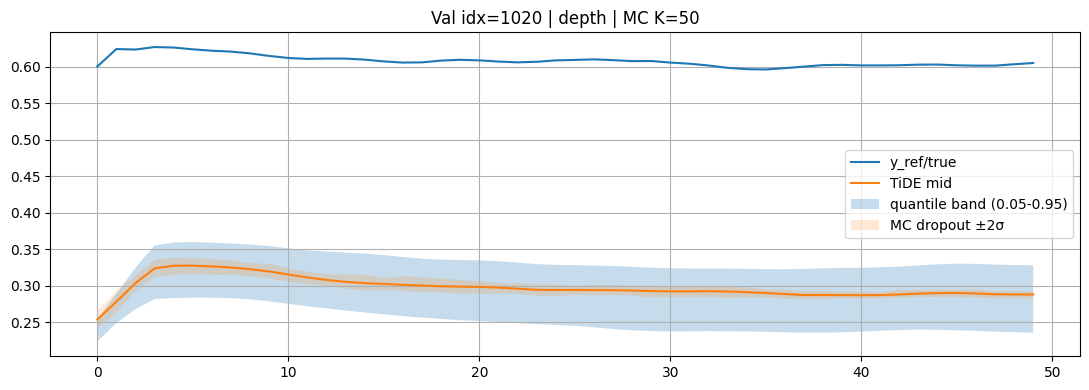

DEBUG TiDE out type: <class 'torch.Tensor'>
DEBUG TiDE out shape: (1, 50, 2, 3)

===== Val idx=50000 | temp | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.894956	 0.704306	 0.730075	 0.691178	 0.731554	 0.045045
01	 0.899998	 0.709184	 0.744166	 0.678228	 0.756352	 0.057332
02	 0.901599	 0.706646	 0.752922	 0.677972	 0.757504	 0.067885
03	 0.898588	 0.702846	 0.750531	 0.665412	 0.749032	 0.072356
04	 0.894810	 0.693997	 0.740600	 0.653630	 0.744704	 0.069273
05	 0.889177	 0.683370	 0.720599	 0.639723	 0.733933	 0.060460
06	 0.887439	 0.670080	 0.694960	 0.626395	 0.677150	 0.081977
07	 0.889777	 0.655006	 0.665764	 0.615038	 0.658665	 0.074085
08	 0.888541	 0.632742	 0.641598	 0.604080	 0.617113	 0.077256
09	 0.887868	 0.616809	 0.626365	 0.593069	 0.624073	 0.075957
10	 0.886555	 0.603246	 0.617090	 0.585641	 0.619855	 0.065767
11	 0.887277	 0.595085	 0.608806	 0.579541	 0.616316	 0.059502
12	 0.891615	 0.596770	 0.601748	 0.574390	 0.601678	 0.072688
13	 0.897549	 0.6042

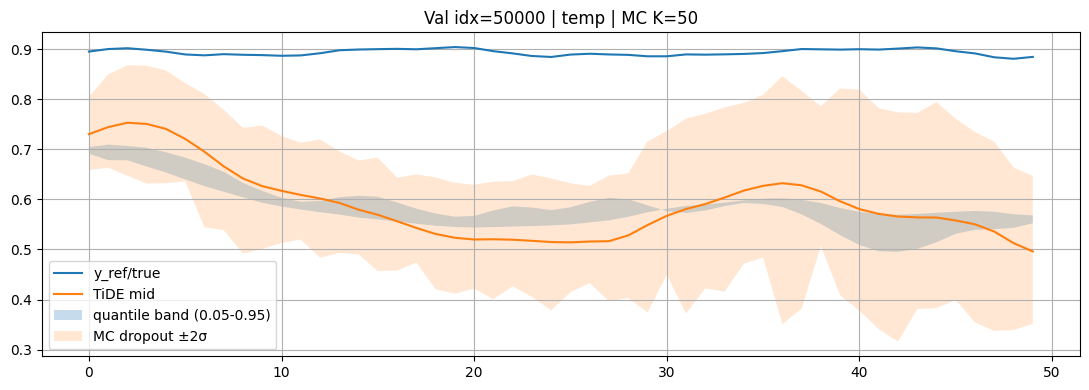


===== Val idx=50000 | depth | T=50 =====
t	true		low		mid		high		mc_mean		mc_std
00	 0.894956	 0.356631	 0.665097	 0.484823	 0.674565	 0.044128
01	 0.899998	 0.298382	 0.581038	 0.439997	 0.575264	 0.058610
02	 0.901599	 0.273504	 0.567375	 0.412936	 0.572503	 0.069677
03	 0.898588	 0.252827	 0.570573	 0.397474	 0.562882	 0.057975
04	 0.894810	 0.236052	 0.576809	 0.385795	 0.581586	 0.063156
05	 0.889177	 0.216916	 0.581287	 0.378505	 0.585367	 0.062862
06	 0.887439	 0.196027	 0.579769	 0.377654	 0.589276	 0.067645
07	 0.889777	 0.173708	 0.572010	 0.381396	 0.569248	 0.055351
08	 0.888541	 0.146719	 0.560462	 0.383045	 0.544654	 0.053239
09	 0.887868	 0.126208	 0.552715	 0.382717	 0.541750	 0.043941
10	 0.886555	 0.109983	 0.548854	 0.379178	 0.546405	 0.042449
11	 0.887277	 0.095795	 0.544245	 0.372839	 0.541635	 0.044166
12	 0.891615	 0.087486	 0.540330	 0.365970	 0.528254	 0.035366
13	 0.897549	 0.086617	 0.544762	 0.362485	 0.548317	 0.044492
14	 0.899045	 0.089715	 0.560275	 0.

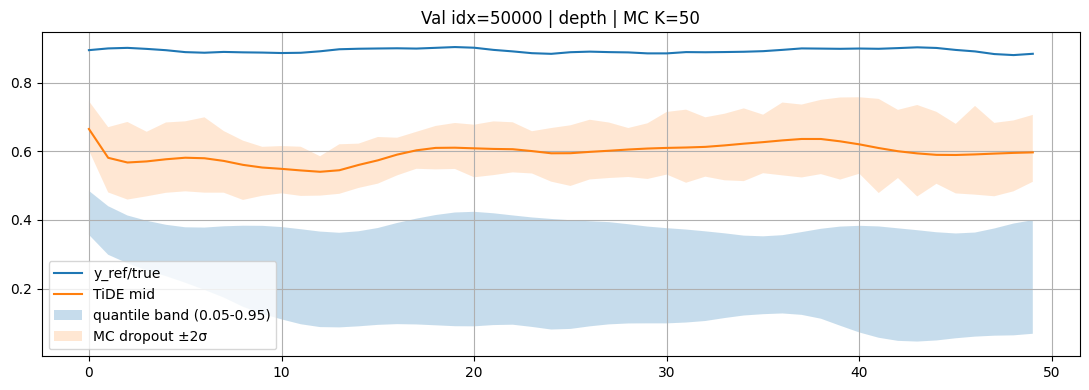

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

indices = [100, 1020, 50000]  # 네가 보고 싶은 val index 3개

policy_ckpt_path = "/home/ftk3187/github/DPC_research/02_DED/7_policy_0113/models_saved/3L_1024H_s1_c3_ep50_roll10_m102400_aug/policy_model.pth"
tide_pkl_path = "TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl"

policy_hidden_dim = 1024   # 네가 학습할 때 쓴 값
policy_n_layers = 3       # 네가 학습할 때 쓴 값

policy_model, TiDE = run_uq_on_val_indices(
    indices=indices,
    val_dataset=val_dataset,
    device=device,
    policy_hidden_dim=policy_hidden_dim,
    policy_n_layers=policy_n_layers,
    policy_ckpt_path=policy_ckpt_path,
    tide_pkl_path=tide_pkl_path,
    mc_K=50
)
